# Определение возраста покупателей

Сетевой супермаркет внедряет систему компьютерного зрения для обработки фотографий покупателей. Фотофиксация в прикассовой зоне поможет определять возраст клиентов, чтобы:
- Анализировать покупки и предлагать товары, которые могут заинтересовать покупателей этой возрастной группы;
- Контролировать добросовестность кассиров при продаже алкоголя.

Нужно построить модель, которая по фотографии определит приблизительный возраст человека. В нашем распоряжении набор фотографий людей с указанием возраста.

## Исследовательский анализ данных

In [7]:
#загрузим нужные нам библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
import os
import numpy as np
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from IPython.core.display import display, HTML
import plotly.express as px

In [8]:
# Меняем ширину контейнера
display(HTML("<style>.container { width:90% !important; }</style>"))

In [10]:
#посмотрим на первые 5 строк
data.head()

,file_name,real_age
0,000000.jpg,4
1,000001.jpg,18
2,000002.jpg,80
3,000003.jpg,50
4,000004.jpg,17


In [11]:
# посмотрим на общую информацию
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7591 entries, 0 to 7590
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   file_name  7591 non-null   object
 1   real_age   7591 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 118.7+ KB


Датафрейм содержит 7,591 запись. В нём 2 столбца: file_name и real_age. Столбец "file_name" содержит имена файлов изображений, например, img_001.jpg, данные типа object. Все значения в этом столбце присутствуют (нет пропусков). Столбец 'real_age' cодержит информацию о возрасте человека на изображении. Тип данных - int64 (целые числа). Все значения в этом столбце присутствуют (нет пропусков).

Чтобы понять, как распределены возраста в датасете, построим график распределения возраста

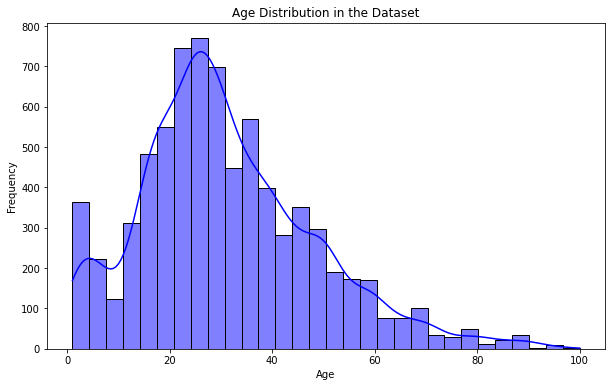

In [12]:
#построим график распределения возраста
plt.figure(figsize=(10, 6))
sns.histplot(data['real_age'], kde=True, bins=30, color='blue')
plt.title('Age Distribution in the Dataset')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [17]:
# Построим график распределения возраста plotly
fig = px.histogram(
    data,
    x='real_age',
    marginal='box',  
    opacity=0.6, 
    barmode='overlay',  
    title='Distribution of Age in the Dataset' 
)

# Немного кастомизируем график
fig.update_traces(marker=dict(color='teal', line=dict(color='black', width=1)))
fig.update_layout(
    title=dict(
        text='Age Distribution in the Dataset',
        font=dict(size=24, family='Arial', color='darkblue'),
        x=0.5,  
        xanchor='center'
    ),
    xaxis=dict(
        title='Age (Years)',  
        titlefont=dict(size=18),
        tickfont=dict(size=14),
        showgrid=True, 
        gridcolor='lightgrey'
    ),
    yaxis=dict(
        title='Frequency',  
        titlefont=dict(size=18),
        tickfont=dict(size=14),
        showgrid=True,
        gridcolor='lightgrey'
    ),
    plot_bgcolor='white',  
    paper_bgcolor='lightgrey'  
)

# Покажем график
fig.show()

In [14]:
data.describe()

,real_age
count,7591.000000
mean,31.201159
std,17.145060
min,1.000000
25%,20.000000
50%,29.000000
75%,41.000000
max,100.000000


В данных представлены изображения людей возрастом от 1 года до 100 лет. Распределение возрастов сдвинуто к более молодым возрастам, так как медиана (29 лет) ниже среднего значения (31.2 года). Стандартное отклонение равно 17.1, что говорит о умеренной степени разброса возрастов относительно среднего. 25% людей имеют возраст 20 лет или меньше. 75% людей имеют возраст 41 год или меньше. Также можно отметить бимодальность распределения, что может говорить о разных источниках, возможно. Наблюдаются некоторые отдельные пики - это, возможно, результаты округления

Чтобы понять, как устроен датасет, визуализируем несколько изображений из папки /final_files, используя метки из CSV.

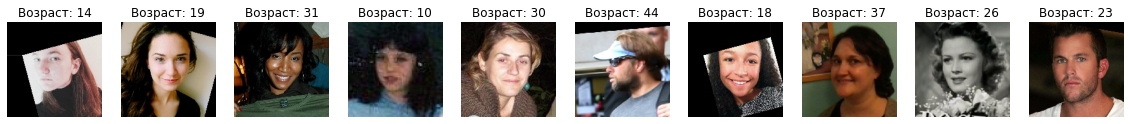

In [15]:
#напишем функцию для отображения случайных изображений
def show_random_images(data, img_dir, num_images=10):
    fig, axes = plt.subplots(1, num_images, figsize=(20, 20))
    for i, ax in enumerate(axes):
        random_index = data.sample(1).index[0]
        img_path = os.path.join(img_dir, data.loc[random_index, 'file_name'])
        img = image.load_img(img_path, target_size=(150, 150))
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(f"Возраст: {data.loc[random_index, 'real_age']}")
    plt.show()

#выведем на экран 10 случайных фотографий
show_random_images(data, '/datasets/faces/final_files', num_images=10)

В представленных случайных 10 изображениях мы видим фотографии 10 людей возрастом от 1 года до 53 лет женского и мужского полов. Фотографии есть как в анфас, так и в профиль с разным уровнем яркости, разными оттенками (есть черно-белые фотографии), разные выражения лиц. Изображения выровнены, что важно для обработки и анализа.

### Вывод

Возрасты в датасете (датафрейм содержит 7,591 запись) распределены неравномерно, с преобладанием молодых возрастных групп. Средний возраст составляет около 31 года, а медиана — 29 лет, что указывает на сдвиг распределения в сторону более молодых групп. Разнообразие возрастов в выборке может помочь модели обобщать результаты для разных возрастных групп. Однако из-за неравномерности распределения потребуется учитывать возможное смещение модели в сторону более распространённых возрастов, например, при настройке модели и выборе метрик, таких как MAE, чтобы модель не игнорировала редкие возрастные группы. Изображения лиц включают лица людей обоих полов, с разными ракурсами (анфас и профиль), различным уровнем яркости и экспрессией. Такое разнообразие помогает обучить модель более универсально, чтобы она могла распознавать лица при разных условиях съёмки. Наличие разной яркости и углов обзора может усложнить задачу модели, потребуя дополнительного предобучения или обработки изображений. Разнообразие в условиях съёмки потребует использования аугментаций, таких как вращение, изменение яркости, масштабирование, для улучшения устойчивости модели к вариативности данных. Возможно потребуется обработка данных, включая нормализацию изображений и исключение аномальных данных, если такие найдутся.

## Обучение модели

Перенесите сюда код обучения модели и её результат вывода на экран.


(Код в этом разделе запускается в отдельном GPU-тренажёре, поэтому оформлен не как ячейка с кодом, а как код в текстовой ячейке)

```python

# Загружаем данные для обучения, применяя аугментации и нормализацию.
def load_train(path):
    labels = pd.read_csv(path + 'labels.csv')
    train_datagen = ImageDataGenerator(
        rescale=1./255, 
        validation_split=0.2,
        horizontal_flip=True, 
        vertical_flip=True, 
        rotation_range=90, 
        width_shift_range=0.2, 
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        brightness_range=[0.8, 1.2]
    )
    
    train_data = train_datagen.flow_from_dataframe(
        dataframe=labels,
        directory=path + 'final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=16,
        class_mode='raw',
        subset='training',
        seed=12345
    )
    return train_data

# Загружаем данные для проверки модели (валидации), применяя только нормализацию.
def load_test(path):
    labels = pd.read_csv(path + 'labels.csv')
    test_datagen = ImageDataGenerator(
        rescale=1./255, 
        validation_split=0.25
    )
    
    test_data = test_datagen.flow_from_dataframe(
        dataframe=labels,
        directory=path + 'final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=16,
        class_mode='raw',
        subset='validation',
        seed=12345
    )
    return test_data

# Создадим архитектуру модели для предсказания возраста.
def create_model(input_shape, l2_reg=0.0001):  
    backbone = ResNet50(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )
    # Используем ResNet50 как основы (backbone) с весами, предобученными на ImageNet
    model = Sequential([
        backbone,
        GlobalAveragePooling2D(),
        # Добавим полносвязный слой (Dense) с одной нейронной и активацией ReLU для предсказания возраста
        Dense(1, activation='relu', kernel_regularizer=l2(l2_reg))  
    ])
    model.compile(optimizer=Adam(learning_rate=1e-4), loss='mse', metrics=['mae'])
    return model

# Запустим процесс обучения модели на тренировочных данных с периодической проверкой на валидационных данных.
def train_model(model, train_data, test_data, epochs=13, batch_size= None):
    # Останавливаем обучение, если валидационная ошибка не уменьшается в течение 5 эпох. 
    # Восстанавливаем веса модели с минимальной валидационной ошибкой.
    early_stopping = EarlyStopping(patience=5, restore_best_weights=True)
    # Уменьшаем скорость обучения в 5 раз, если валидационная ошибка не уменьшается в течение 3 эпох.
    reduce_lr = ReduceLROnPlateau(factor=0.2, patience=3, verbose=1)
    # Обучаем модель
    model.fit(
        train_data,
        validation_data=test_data,
        epochs=epochs,
        verbose=2,
        batch_size= batch_size,
        callbacks=[early_stopping, reduce_lr]
    )
    
    return model 

```

Данные загружаются, проходят через процесс нормализации и аугментации, после чего модель обучается на тренировочных данных с периодическим контролем качества на валидации. Регуляризация и контроль скорости обучения помогают избежать переобучения и повысить стабильность.

Получили следующие результаты модели:

```
Epoch 1/13
2024-12-04 17:43:09.104498: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcublas.so.10
2024-12-04 17:43:09.436382: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcudnn.so.7
380/380 - 141s - loss: 259.8854 - mae: 12.1225 - val_loss: 627.1840 - val_mae: 20.0322
Epoch 2/13
380/380 - 132s - loss: 153.4668 - mae: 9.5330 - val_loss: 164.2777 - val_mae: 9.9939
Epoch 3/13
380/380 - 132s - loss: 138.3228 - mae: 8.9850 - val_loss: 147.3918 - val_mae: 9.2533
Epoch 4/13
380/380 - 133s - loss: 131.4017 - mae: 8.7732 - val_loss: 158.9543 - val_mae: 9.7773
Epoch 5/13
380/380 - 134s - loss: 123.5329 - mae: 8.4968 - val_loss: 132.1560 - val_mae: 8.5162
Epoch 6/13
380/380 - 131s - loss: 114.4189 - mae: 8.2006 - val_loss: 92.6471 - val_mae: 7.4301
Epoch 7/13
380/380 - 133s - loss: 109.5940 - mae: 8.0070 - val_loss: 110.3037 - val_mae: 7.9594
Epoch 8/13
380/380 - 143s - loss: 107.2380 - mae: 7.8772 - val_loss: 110.9571 - val_mae: 8.0724
Epoch 9/13

Epoch 00009: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
380/380 - 142s - loss: 99.4923 - mae: 7.6030 - val_loss: 94.2983 - val_mae: 7.2748
Epoch 10/13
380/380 - 143s - loss: 79.2236 - mae: 6.8320 - val_loss: 94.8230 - val_mae: 7.2239
Epoch 11/13
380/380 - 143s - loss: 73.5209 - mae: 6.5578 - val_loss: 83.2171 - val_mae: 6.8117
Epoch 12/13
380/380 - 139s - loss: 69.4156 - mae: 6.4400 - val_loss: 86.4284 - val_mae: 6.8674
Epoch 13/13
380/380 - 133s - loss: 65.5795 - mae: 6.1939 - val_loss: 79.6988 - val_mae: 6.6822

```

## Анализ обученной модели

Анализ результатов обучения модели показывает, что на протяжении 13 эпох наблюдается устойчивое улучшение метрик на тренировочной и валидационной выборках. В начале обучения ошибка модели была значительной: средняя абсолютная ошибка (MAE) на тренировочной выборке составила 12.12, а на валидационной — 20.03. Это указывает на первоначальные трудности модели в прогнозировании возраста. С каждой эпохой ошибка последовательно уменьшалась, что свидетельствует об успешном обучении. Уже к пятой эпохе MAE на тренировочной выборке снизилась до 8.50, а на валидационной — до 8.52. Начиная с шестой эпохи, модель продемонстрировала заметное улучшение, сократив MAE на валидационной выборке до 7.43, что свидетельствует о способности модели лучше справляться с прогнозированием возраста. Применение механизма уменьшения скорости обучения после девятой эпохи позволило модели стабилизировать улучшение метрик. Это помогло избежать переобучения и обеспечило дальнейшее снижение ошибки. На последней, тринадцатой эпохе MAE составила 6.19 на тренировочной выборке и 6.68 на валидационной, что является хорошим результатом. Снижение MAE на валидационной выборке с 20.03 до 6.68 лет демонстрирует, что модель успешно обучилась и способна адекватно предсказывать возраст на новых данных. При этом сохраняется незначительное расхождение между метриками тренировочной и валидационной выборок, что свидетельствует о хорошем балансе между обучением и обобщающей способностью модели.

# Общий вывод

Задача проекта состояла в разработке системы компьютерного зрения для сетевого супермаркета «Хлеб-Соль», целью которой является автоматическое определение возраста клиентов на основе фотографий, сделанных в прикассовой зоне. Система предназначена для более точной сегментации аудитории и контроля за продажей возрастных товаров, таких как алкоголь. Это должно было позволить предлагать персонализированные рекомендации покупателям, а также проверять соблюдение кассирами правил продажи. В рамках проекта был использован набор данных, включающий 7591 запись с информацией о возрасте и именах файлов изображений. Возраст людей в этом наборе данных варьировался от 1 до 100 лет, при этом распределение было смещено в сторону молодых возрастных групп: средний возраст составил 31,2 года, а медиана — 29 лет. На изображениях присутствовали лица обоих полов, снятые под различными углами, с разной яркостью и выражениями лиц, что значительно усложняло задачу. Для повышения устойчивости модели применялись методы аугментации данных, такие как вращение, изменение яркости и масштабирование.
Для построения модели была использована архитектура ResNet50 в качестве предобученной базы с добавлением финального слоя для регрессии возраста. Данные были разделены на обучающую и валидационную (тестовую) выборки, с применением нормализации и аугментации изображений. В процессе обучения использовался Adam-оптимизатор, регуляризация и механизмы снижения скорости обучения при стабилизации валидационных метрик.
По итогам обучения модель продемонстрировала снижение средней абсолютной ошибки (MAE) на валидационной выборке до 6.68, что является хорошим результатом, учитывая разнообразие и распределение данных. Модель показала высокую устойчивость к вариативности изображений и готова для использования на новых данных, что способствует решению задач сегментации аудитории и контроля за продажей возрастных товаров.
Для дальнейшего улучшения результатов модели можно будет рассмотреть расширение обучающей выборки за счёт новых изображений, особенно из недопредставленных возрастных категорий (Это поможет модели лучше различать черты, характерные для разных возрастов).  Текущие методы аугментации (вращение, изменение яркости, масштабирование) можно дополнить новыми техниками, такими как добавление шумов, или использование методов генеративного обучения (например, GANs) для создания синтетических данных. Можно еще тщательнее сделать подбор гиперпараметров модели, включая размер шага обучения, коэффициенты регуляризации и параметры слоев, что потенциально может привести к лучшему обучению модели. Можно попробовать использовать более сложные архитектуры помимо ResNet50. Может поможет также более тщательная очистка изображений, нормализация яркости и цвета или выделение отдельных лиц на изображениях.